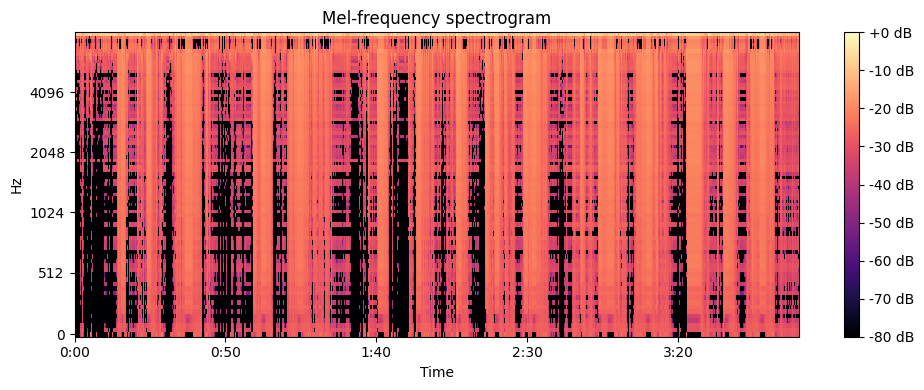

In [35]:
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
mel_spec = '/home/nikhil/jukedrummer/vqvae_mels/37_segment_1.npy'
# mel = np.load(mel_spec)
mel = np.load(mel_spec)
plt.figure(figsize=(10, 4))
librosa.display.specshow(librosa.power_to_db(mel, ref=np.max), y_axis='mel', fmax=8000, x_axis='time')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-frequency spectrogram')
plt.tight_layout()



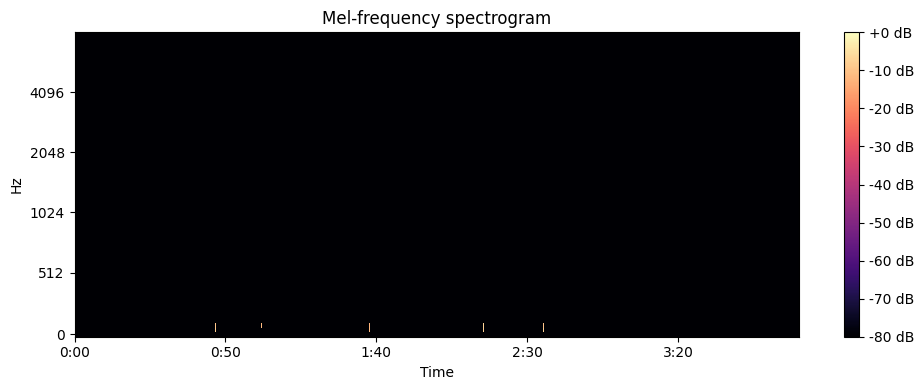

In [34]:
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
mel_spec = '/home/nikhil/jukedrummer/data/mel/target/37_segment_2.npy'
mel = np.load(mel_spec)
plt.figure(figsize=(10, 4))
librosa.display.specshow(librosa.power_to_db(mel, ref=np.max), y_axis='mel', fmax=8000, x_axis='time')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-frequency spectrogram')
plt.tight_layout()


In [12]:
import shutil
import os

def copy_files(source_folder, destination_folder, num_files=64):
    """
    Copies a specified number of files from the source folder to the destination folder.
    :param source_folder: Path to the source folder
    :param destination_folder: Path to the destination folder
    :param num_files: Number of files to copy (default is 32)
    """
    # Debug paths
    print(f"Source folder: {source_folder}")
    print(f"Destination folder: {destination_folder}")

    # Create destination folder if it doesn't exist
    try:
        if not os.path.exists(destination_folder):
            os.makedirs(destination_folder)
    except PermissionError:
        print(f"Error: Permission denied for creating '{destination_folder}'.")
        return

    # List files in the source folder
    try:
        files = os.listdir(source_folder)[:num_files]
    except FileNotFoundError:
        print(f"Error: The source folder '{source_folder}' does not exist.")
        return
    except PermissionError:
        print(f"Error: Permission denied for accessing '{source_folder}'.")
        return

    # Copy files
    for file_name in files:
        full_file_name = os.path.join(source_folder, file_name)
        if os.path.isfile(full_file_name):
            try:
                shutil.copy(full_file_name, destination_folder)
                print(f"Copied: {full_file_name} -> {destination_folder}")
            except PermissionError:
                print(f"Error: Permission denied for copying '{full_file_name}' to '{destination_folder}'.")
            except Exception as e:
                print(f"Error: Failed to copy '{full_file_name}' to '{destination_folder}'. Reason: {e}")

# Example usage
source = '/home/nikhil/jukedrummer/data_all/audio/others/'
destination = "/home/nikhil/jukedrummer/data/audio/others/"
copy_files(source, destination)

Source folder: /home/nikhil/jukedrummer/data_all/audio/others/
Destination folder: /home/nikhil/jukedrummer/data/audio/others/
Copied: /home/nikhil/jukedrummer/data_all/audio/others/zz_92_segment_4.wav -> /home/nikhil/jukedrummer/data/audio/others/
Copied: /home/nikhil/jukedrummer/data_all/audio/others/190_segment_3.wav -> /home/nikhil/jukedrummer/data/audio/others/
Copied: /home/nikhil/jukedrummer/data_all/audio/others/jy_50_segment_1.wav -> /home/nikhil/jukedrummer/data/audio/others/
Copied: /home/nikhil/jukedrummer/data_all/audio/others/jy_30_segment_2.wav -> /home/nikhil/jukedrummer/data/audio/others/
Copied: /home/nikhil/jukedrummer/data_all/audio/others/jy_59_segment_4.wav -> /home/nikhil/jukedrummer/data/audio/others/
Copied: /home/nikhil/jukedrummer/data_all/audio/others/jy_42_segment_2.wav -> /home/nikhil/jukedrummer/data/audio/others/
Copied: /home/nikhil/jukedrummer/data_all/audio/others/113_segment_4.wav -> /home/nikhil/jukedrummer/data/audio/others/
Copied: /home/nikhil/ju

In [50]:
import numpy as np
source = '/home/nikhil/jukedrummer/data/mel/target/'
def find_max_array_size(folder_path):
    """
    Finds the maximum shape of numpy arrays in a folder.
    :param folder_path: Path to the folder containing numpy array files
    """
    max_shape = None
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.npy'):
            file_path = os.path.join(folder_path, file_name)
            try:
                array = np.load(file_path)
                if max_shape is None or array.shape > max_shape:
                    max_shape = array.shape
            except Exception as e:
                print(f"Error loading '{file_path}': {e}")
    return max_shape
max_shape = find_max_array_size(source)
print(f"Maximum shape of numpy arrays in '{source}': {max_shape}")



Maximum shape of numpy arrays in '/home/nikhil/jukedrummer/data/mel/target/': (80, 10341)


In [51]:
!uv run try.py

Converted /home/nikhil/jukedrummer/data/audio/target/za_59_segment_1.mp3 to /home/nikhil/jukedrummer/data/audio/target_wav/za_59_segment_1.wav
Converted /home/nikhil/jukedrummer/data/audio/target/jy_64_segment_1.mp3 to /home/nikhil/jukedrummer/data/audio/target_wav/jy_64_segment_1.wav
Converted /home/nikhil/jukedrummer/data/audio/target/107_segment_3.mp3 to /home/nikhil/jukedrummer/data/audio/target_wav/107_segment_3.wav
Converted /home/nikhil/jukedrummer/data/audio/target/za_97_segment_1.mp3 to /home/nikhil/jukedrummer/data/audio/target_wav/za_97_segment_1.wav
Converted /home/nikhil/jukedrummer/data/audio/target/jy_16_segment_5.mp3 to /home/nikhil/jukedrummer/data/audio/target_wav/jy_16_segment_5.wav
Converted /home/nikhil/jukedrummer/data/audio/target/zz_41_segment_2.mp3 to /home/nikhil/jukedrummer/data/audio/target_wav/zz_41_segment_2.wav
Converted /home/nikhil/jukedrummer/data/audio/target/zz_47_segment_2.mp3 to /home/nikhil/jukedrummer/data/audio/target_wav/zz_47_segment_2.wav
Tra

In [2]:
# code to remove all mp3 files from a directory
import os
def remove_mp3_files(directory):
    for filename in os.listdir(directory):
        if filename.endswith('.mp3'):
            file_path = os.path.join(directory, filename)
            try:
                os.remove(file_path)
                print(f"Removed: {file_path}")
            except Exception as e:
                print(f"Error removing {file_path}: {e}")

remove_mp3_files('/home/nikhil/jukedrummer/data/audio/target')

Removed: /home/nikhil/jukedrummer/data/audio/target/za_59_segment_1.mp3
Removed: /home/nikhil/jukedrummer/data/audio/target/jy_64_segment_1.mp3
Removed: /home/nikhil/jukedrummer/data/audio/target/107_segment_3.mp3
Removed: /home/nikhil/jukedrummer/data/audio/target/za_97_segment_1.mp3
Removed: /home/nikhil/jukedrummer/data/audio/target/jy_16_segment_5.mp3
Removed: /home/nikhil/jukedrummer/data/audio/target/zz_41_segment_2.mp3
Removed: /home/nikhil/jukedrummer/data/audio/target/zz_47_segment_2.mp3
Removed: /home/nikhil/jukedrummer/data/audio/target/zz_28_segment_4.mp3
Removed: /home/nikhil/jukedrummer/data/audio/target/52_segment_7.mp3
Removed: /home/nikhil/jukedrummer/data/audio/target/zz_22_segment_2.mp3
Removed: /home/nikhil/jukedrummer/data/audio/target/48_segment_1.mp3
Removed: /home/nikhil/jukedrummer/data/audio/target/zz_93_segment_1.mp3
Removed: /home/nikhil/jukedrummer/data/audio/target/zz_42_segment_2.mp3
Removed: /home/nikhil/jukedrummer/data/audio/target/zz_117_segment_1.mp3